* Tevin - Code + Section 2 + 3.
* Mukul take section 1
* Chandrashekar take section 4

* Group Project Part 1 - Heart Disease Prediction
* Team: Group 5 - Mukul Kumar Dhali, Chandrashekar Reddy Mothukupally, Tevin Parboosingh, Neviar Rawlinson
* PhDAI-732: Fundamentals of AI-Enabled Systems

---



Run each cell in order. Sections follow the project requirements.

1. Data Collection and Exploration
2. Preprocessing
3. Initial Model Development
4. Evaluation

# Data Preparation and Cleanse

In [1]:
# Prerequisites - pandas, numpy, sklearn, matplotlib, seaborn
# Heart Disease UCI dataset loads directly from UCI ML repository

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# Loads the Heart Disease UCI dataset. Has 303 patients, 14 features, binary target (0=no disease, 1=disease)

# Source: UCI Machine Learning Repository via GitHub mirror
url = "https://raw.githubusercontent.com/Sohila-Khaled-Abbas/ab-testing-marketing-conversion/main/data/marketing_AB.csv"

# Using the standard Cleveland Heart Disease dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns, na_values='?')

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['target'].value_counts())

Dataset loaded successfully.
Shape: (303, 14)

First few rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
d

In [4]:
# Convert target to binary - original has values 0-4
# 0 = no disease, 1-4 = disease present
df['target'] = (df['target'] > 0).astype(int)

print("Binary target distribution:")
print(df['target'].value_counts())
print(f"\nDisease prevalence: {df['target'].mean()*100:.1f}%")

# Basic statistics
print("\nDescriptive Statistics:")
print(df.describe().round(2))

Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64

Disease prevalence: 45.9%

Descriptive Statistics:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.44    0.68    3.16    131.69  246.69    0.15     0.99   149.61   
std      9.04    0.47    0.96     17.60   51.78    0.36     0.99    22.88   
min     29.00    0.00    1.00     94.00  126.00    0.00     0.00    71.00   
25%     48.00    0.00    3.00    120.00  211.00    0.00     0.00   133.50   
50%     56.00    1.00    3.00    130.00  241.00    0.00     1.00   153.00   
75%     61.00    1.00    4.00    140.00  275.00    0.00     2.00   166.00   
max     77.00    1.00    4.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  303.00   303.00  303.00  299.00  301.00  303.00  
mean     0.33     1.04    1.60    0.67    4.73    0.46  
std 

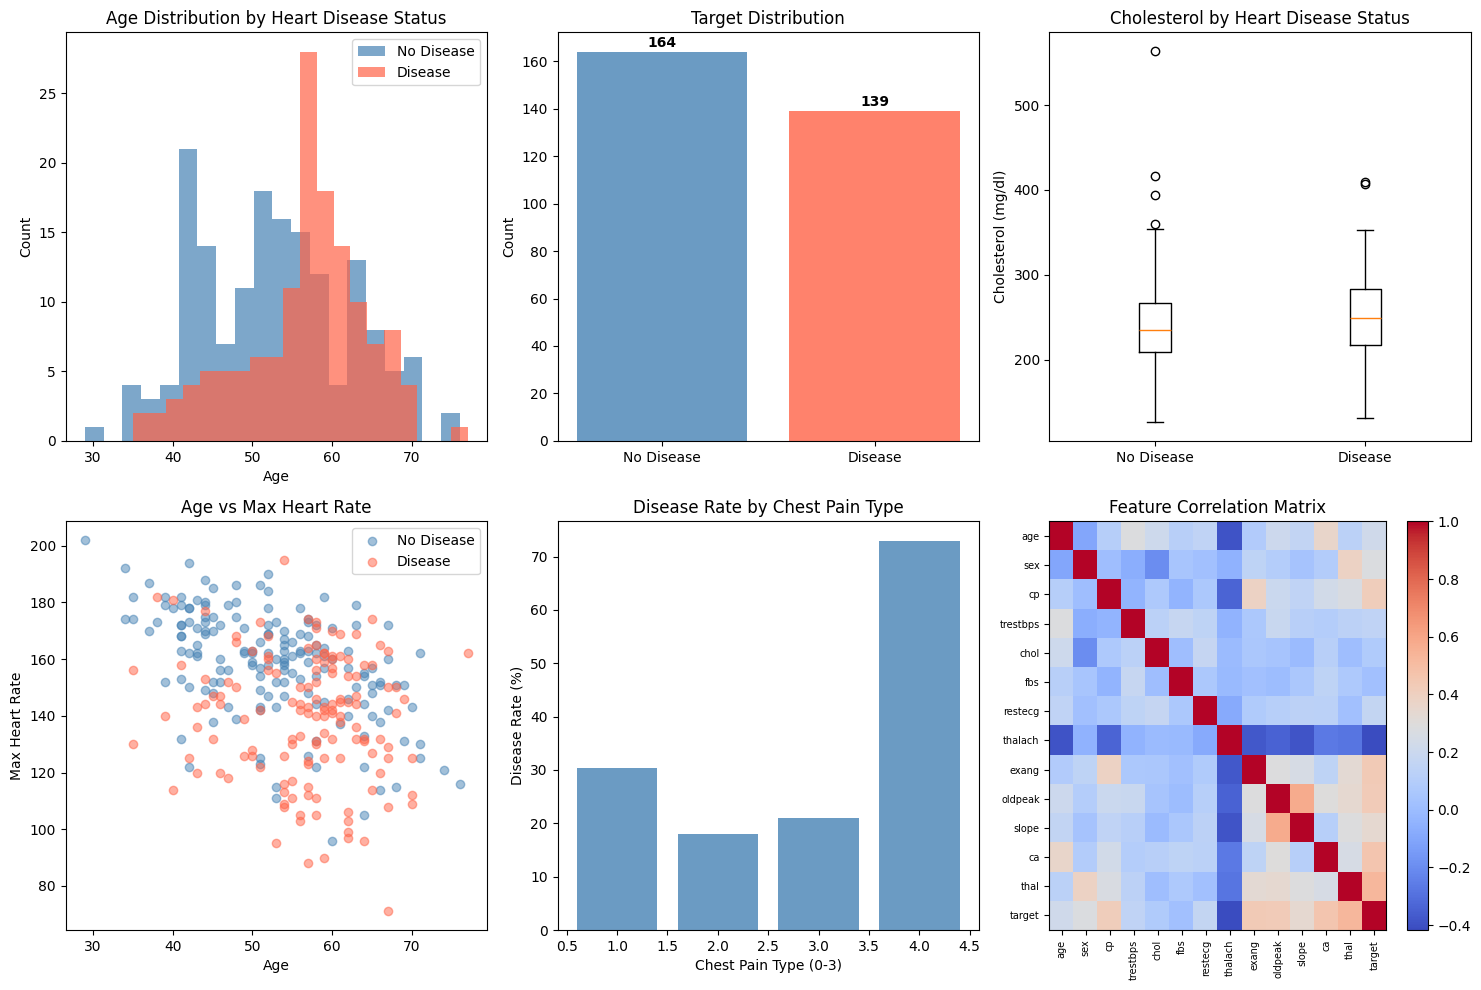

EDA plots saved.


In [6]:
# EDA - visualize key features

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Age distribution by target
axes[0,0].hist(df[df['target']==0]['age'], bins=20, alpha=0.7, color='steelblue', label='No Disease')
axes[0,0].hist(df[df['target']==1]['age'], bins=20, alpha=0.7, color='tomato', label='Disease')
axes[0,0].set_title('Age Distribution by Heart Disease Status')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Target distribution
target_counts = df['target'].value_counts()
axes[0,1].bar(['No Disease', 'Disease'], target_counts.values, color=['steelblue', 'tomato'], alpha=0.8)
axes[0,1].set_title('Target Distribution')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(target_counts.values): axes[0,1].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Cholesterol by target
axes[0,2].boxplot([df[df['target']==0]['chol'], df[df['target']==1]['chol']], labels=['No Disease', 'Disease'])
axes[0,2].set_title('Cholesterol by Heart Disease Status')
axes[0,2].set_ylabel('Cholesterol (mg/dl)')

# Max heart rate by target
axes[1,0].scatter(df[df['target']==0]['age'], df[df['target']==0]['thalach'], alpha=0.5, color='steelblue', label='No Disease')
axes[1,0].scatter(df[df['target']==1]['age'], df[df['target']==1]['thalach'], alpha=0.5, color='tomato', label='Disease')
axes[1,0].set_title('Age vs Max Heart Rate')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Max Heart Rate')
axes[1,0].legend()

# Chest pain type
cp_disease = df.groupby('cp')['target'].mean() * 100
axes[1,1].bar(cp_disease.index, cp_disease.values, color='steelblue', alpha=0.8)
axes[1,1].set_title('Disease Rate by Chest Pain Type')
axes[1,1].set_xlabel('Chest Pain Type (0-3)')
axes[1,1].set_ylabel('Disease Rate (%)')

# Correlation heatmap
corr = df.corr(numeric_only=True)
im = axes[1,2].imshow(corr, cmap='coolwarm', aspect='auto')
axes[1,2].set_xticks(range(len(corr.columns)))
axes[1,2].set_yticks(range(len(corr.columns)))
axes[1,2].set_xticklabels(corr.columns, rotation=90, fontsize=7)
axes[1,2].set_yticklabels(corr.columns, fontsize=7)
axes[1,2].set_title('Feature Correlation Matrix')
plt.colorbar(im, ax=axes[1,2])

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved.")

# Preprocessing - handling missing values, encoding, and scaling

In [7]:
# Handle missing values - ca and thal have some NaN values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing values with median
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Define features and target
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X = df[feature_cols].values
y = df['target'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Class balance: {y.mean()*100:.1f}% positive cases")

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Feature matrix shape: (303, 13)
Target vector shape: (303,)
Class balance: 45.9% positive cases


In [9]:
# Train test split 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Train class balance: {y_train.mean()*100:.1f}%")
print(f"Test class balance: {y_test.mean()*100:.1f}%")

Training set: (242, 13)
Test set: (61, 13)
Train class balance: 45.9%
Test class balance: 45.9%


# Model Development - Logistic Regression

So as our baseline Logistic regression makes sense as the right starting point for binary medical classification. It is fast, interpretable, and the coefficients tell us which features drive risk

In [12]:
# Train logistic regression baseline model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained.")
print("\nModel coefficients (feature importance):")
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr_model.coef_[0]}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

Logistic Regression model trained.

Model coefficients (feature importance):
 Feature  Coefficient
      ca     1.107898
    thal     0.677821
     sex     0.655563
      cp     0.543483
   exang     0.383642
   slope     0.354072
 thalach    -0.348486
trestbps     0.313655
     fbs    -0.220560
 restecg     0.217329
    chol     0.215375
 oldpeak     0.149953
     age    -0.103159


In [13]:
# Evaluate on test set
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("=== Logistic Regression - Test Set Performance ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

=== Logistic Regression - Test Set Performance ===
Accuracy:  0.8689
Precision: 0.8125
Recall:    0.9286
F1 Score:  0.8667
ROC-AUC:   0.9513

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [15]:
# Cross validation for honest performance estimate
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("5-Fold Cross Validation Results:")
print(f"Scores: {cv_scores.round(4)}")
print(f"Mean:   {cv_scores.mean():.4f}")
print(f"Std:    {cv_scores.std():.4f}")

5-Fold Cross Validation Results:
Scores: [0.9184 0.7755 0.8333 0.8333 0.7708]
Mean:   0.8263
Std:    0.0534


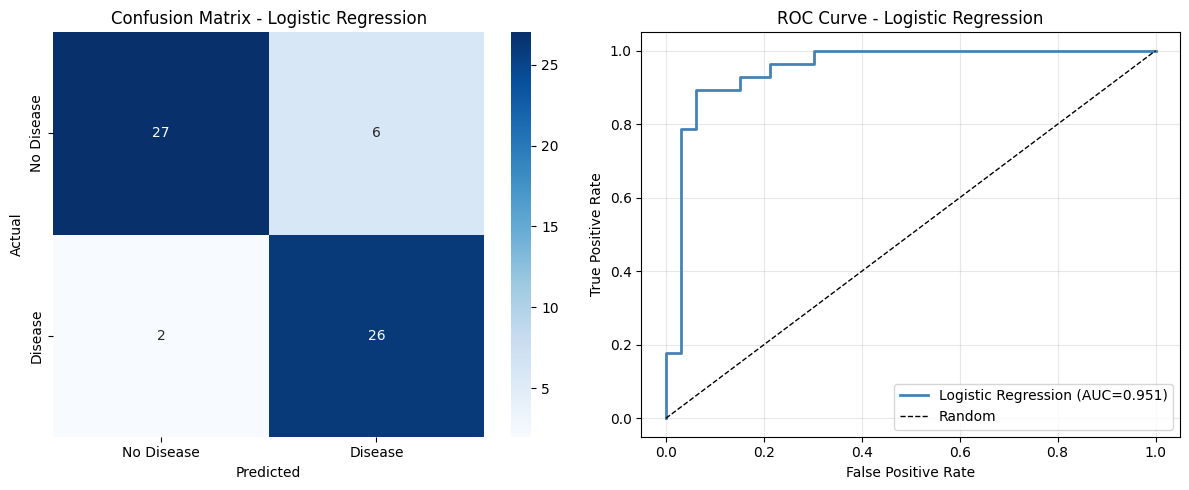

Model evaluation plots saved.

All outputs generated. Bring back the metrics for the report.


In [16]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Logistic Regression (AUC={auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Logistic Regression')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model evaluation plots saved.")

print("\nAll outputs generated. Bring back the metrics for the report.")